# 046 分类指标与排序评价

固定12行案例贯通混淆矩阵、阈值扫描、ROC/AP、平均方式、阳性率变化。先阅读lab.pdf并完成L1-L2纸笔题，再从上到下执行。无模型拟合、无随机数据、无测试阈值选择。

## 1 定位课程与版本
在本单元目录打开Notebook；如果外部启动器使用其他目录，可先设置环境变量 ML046_ROOT 为本机解压后的046路径。

In [1]:
from pathlib import Path
import os, sys, json, csv
root = Path(os.environ.get('ML046_ROOT', Path.cwd())).resolve()
if not (root / 'data/review_scores.csv').is_file():
    raise RuntimeError('Open this notebook from the 046 directory, or set ML046_ROOT.')
sys.path.insert(0, str(root))
import numpy as np
import sklearn
from IPython.display import display, Image
from experiment import load_case, run, counts_at, sweep, prior_weights, library_metrics, average_metrics
print(sys.version.split()[0], np.__version__, sklearn.__version__)

## 2 看每条记录
标签1表示缺陷。评分大小是复核优先级，不保证已校准成概率。

In [2]:
ids, y, s = load_case()
print('id label score predict_at_080')
for i, yi, si in zip(ids, y, s):
    print(i, yi, f'{si:.2f}', int(si >= .80))
print('positive, negative, prevalence:', int(y.sum()), int((1-y).sum()), y.mean())

## 3 不用指标库的逐行计数
先预测，再同时检查真实标签。请先心算L1，再运行。

In [3]:
for t in [.80, .55]:
    c = dict(TP=0, FP=0, FN=0, TN=0)
    for yi, si in zip(y, s):
        pred = si >= t
        key = ('TP' if yi else 'FP') if pred else ('FN' if yi else 'TN')
        c[key] += 1
    tp, fp, fn, tn = (c[k] for k in ['TP','FP','FN','TN'])
    print(t, c, 'P/R/F1/Accuracy:', tp/(tp+fp), tp/(tp+fn), 2*tp/(2*tp+fp+fn), (tp+tn)/len(y))

## 4 真实库核验单阈值
矩阵轴顺序为真实行、预测列、labels=[0,1]。二分类F1明确average=binary。

In [4]:
from sklearn import metrics as m
for t in [.80, .55]:
    pred = s >= t
    print('threshold', t)
    print(m.confusion_matrix(y, pred, labels=[0,1]))
    print(m.precision_recall_fscore_support(y, pred, labels=[0,1], pos_label=1, average='binary', zero_division=0))

## 5 完整同分组扫描
注意0.80只有一行决策，C和D同时入选。空警报精确率的0是报告约定，precision_defined会是False。

In [5]:
rows = sweep(y,s)
print('t TP FP FN TN P R F1 FPR defined')
for row in rows:
    print(row['threshold'], *(round(row[k],6) for k in ['TP','FP','FN','TN','precision','recall','f1','fpr']), row['precision_defined'])

## 6 ROC与PR的端点不能混用
请回答L4：两个阈值数组为什么方向不同？PR最后一个点对应哪个阈值？

In [6]:
fpr,tpr,rt = m.roc_curve(y,s,pos_label=1,drop_intermediate=False)
p,r,pt = m.precision_recall_curve(y,s,pos_label=1,drop_intermediate=False)
print('ROC lengths:', len(fpr),len(tpr),len(rt))
print('ROC thresholds:', rt)
print('ROC FPR:',fpr,'\nROC TPR:',tpr)
print('PR lengths:',len(p),len(r),len(pt))
print('PR thresholds:',pt)
print('PR precision:',p,'\nPR recall:',r)
print('AUC AP PR-trapezoid:',m.roc_auc_score(y,s),m.average_precision_score(y,s,pos_label=1),m.auc(r,p))

## 7 独立Fraction参照
从CSV整数评分重新建立参照，不把sklearn输出当预期答案。完整1134个小例子在终端运行audit.py。

In [7]:
from audit import fraction_reference, run_audit
with (root/'data/review_scores.csv').open(newline='') as f:
    raw = list(csv.DictReader(f))
ref = fraction_reference([int(a['label']) for a in raw],[int(a['score_percent']) for a in raw])
print({k:str(ref[k]) for k in ['auc','ap','pr_trapezoid']})
print(run_audit(exhaustive=False))

## 8 阳性率变化
只改两类混合权重，保持每类内部评分分布。权重计数不是新增或删除真实零件。

In [8]:
for pi in [.10,.25,.50]:
    w = prior_weights(y,s,pi)
    curves = library_metrics(y,s,w)
    print('pi=',pi,'weights=',w)
    print('at .80:',counts_at(y,s,.8,w))
    print('AUC/AP:',curves['auc'],curves['ap'])

## 9 同一预测的四种F1
先看average=None的每类结果与支持度，再解释汇总。

In [9]:
for name, values in average_metrics(y,s).items():
    print(name, values)

## 10 保序不等于同一概率
立方是一个反例，不是拟合的校准器。将阈值也映射到0.512才能保留原决策。

In [10]:
result = run()
print(json.dumps(result['monotone'],indent=2))
if counts_at(y,s,.8) != counts_at(y,s**3,.8**3):
    raise RuntimeError('mapped decision changed')

## 11 从本次计算重建全部图
图像输出到outputs/notebook-figures，不覆盖讲义原图。下方图像是本次执行产生的PNG。

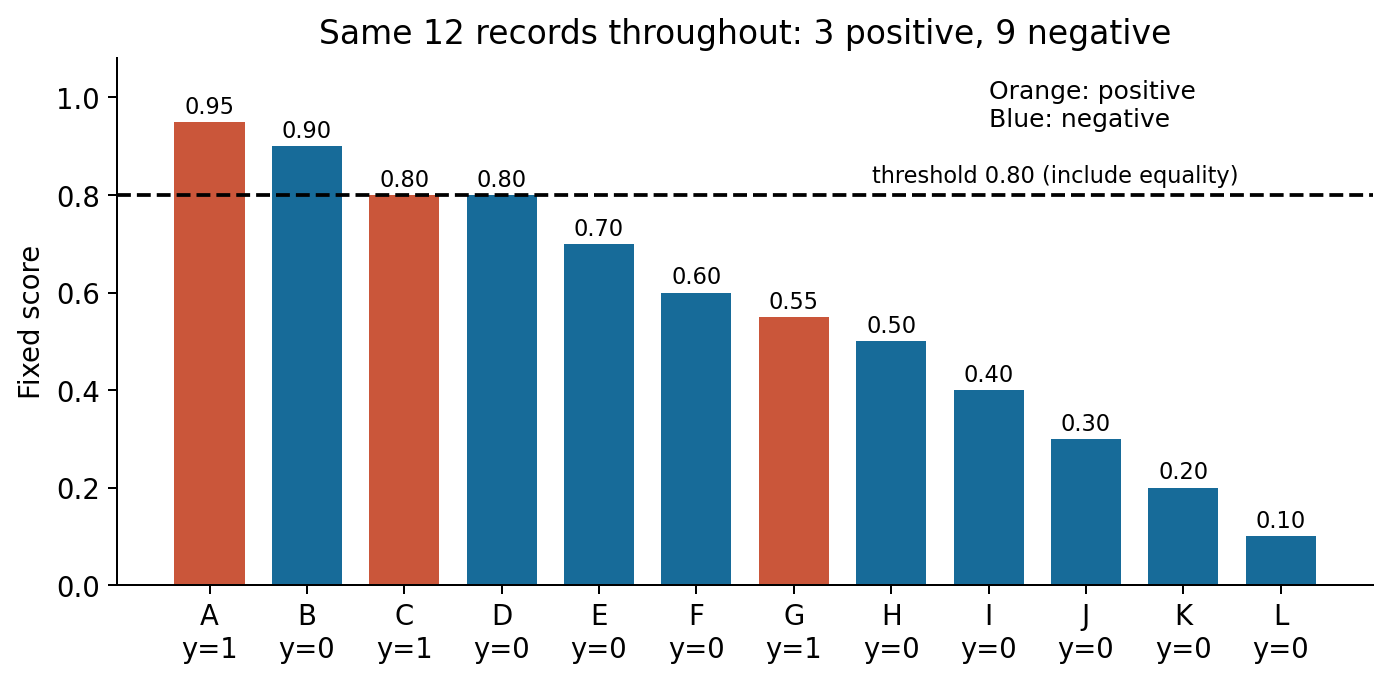

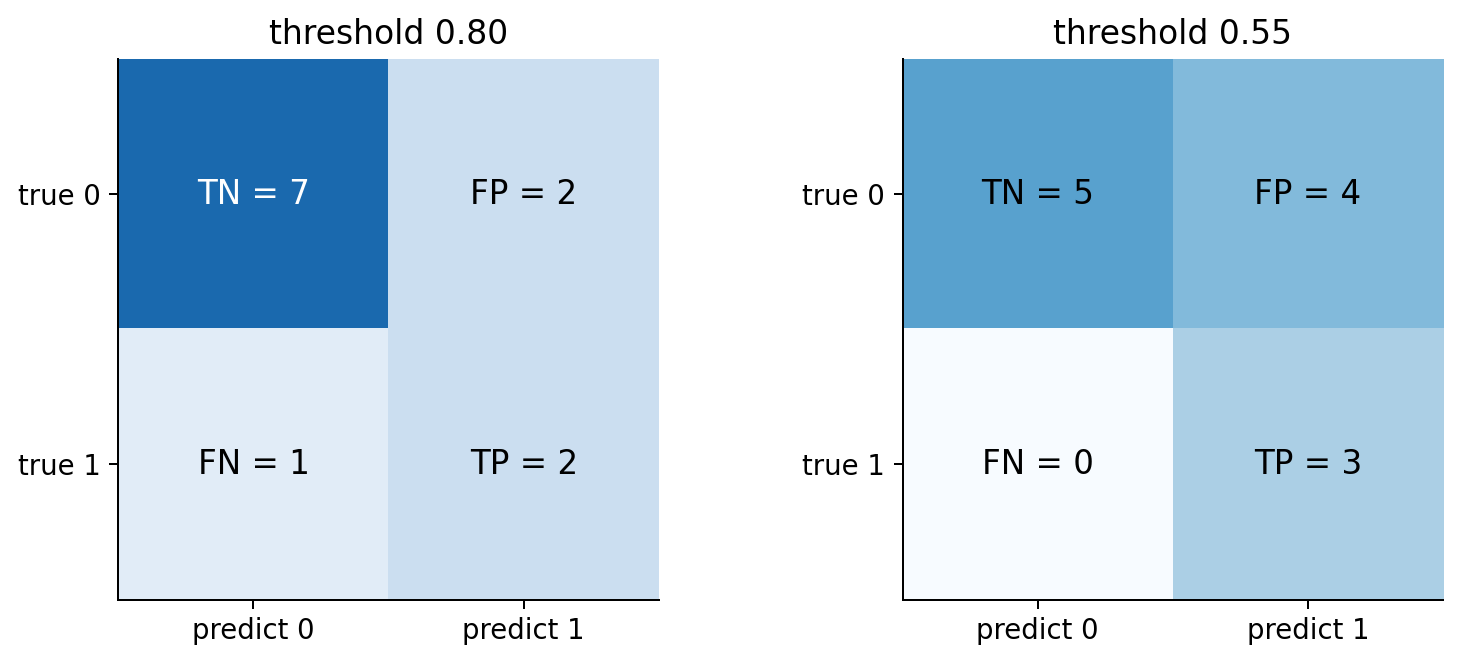

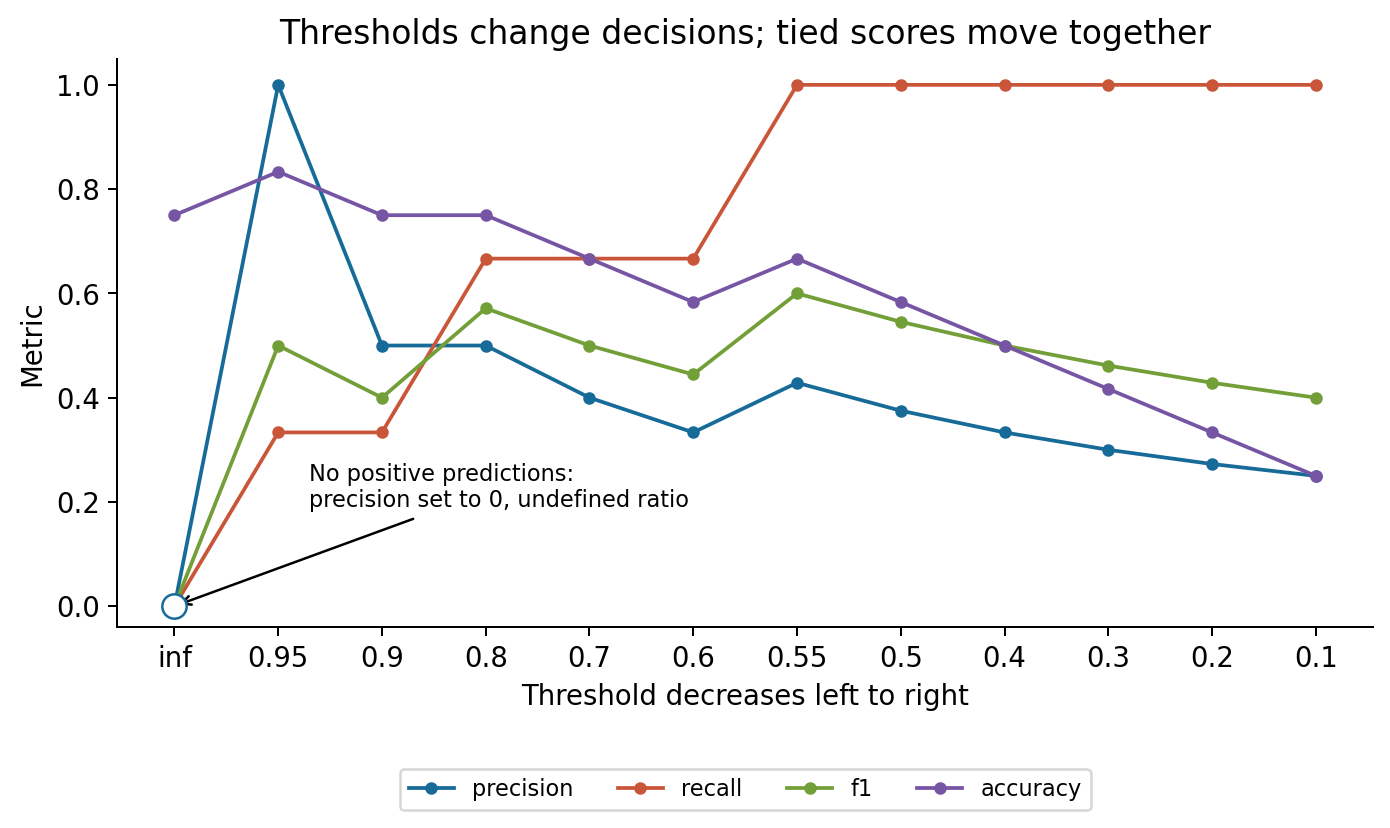

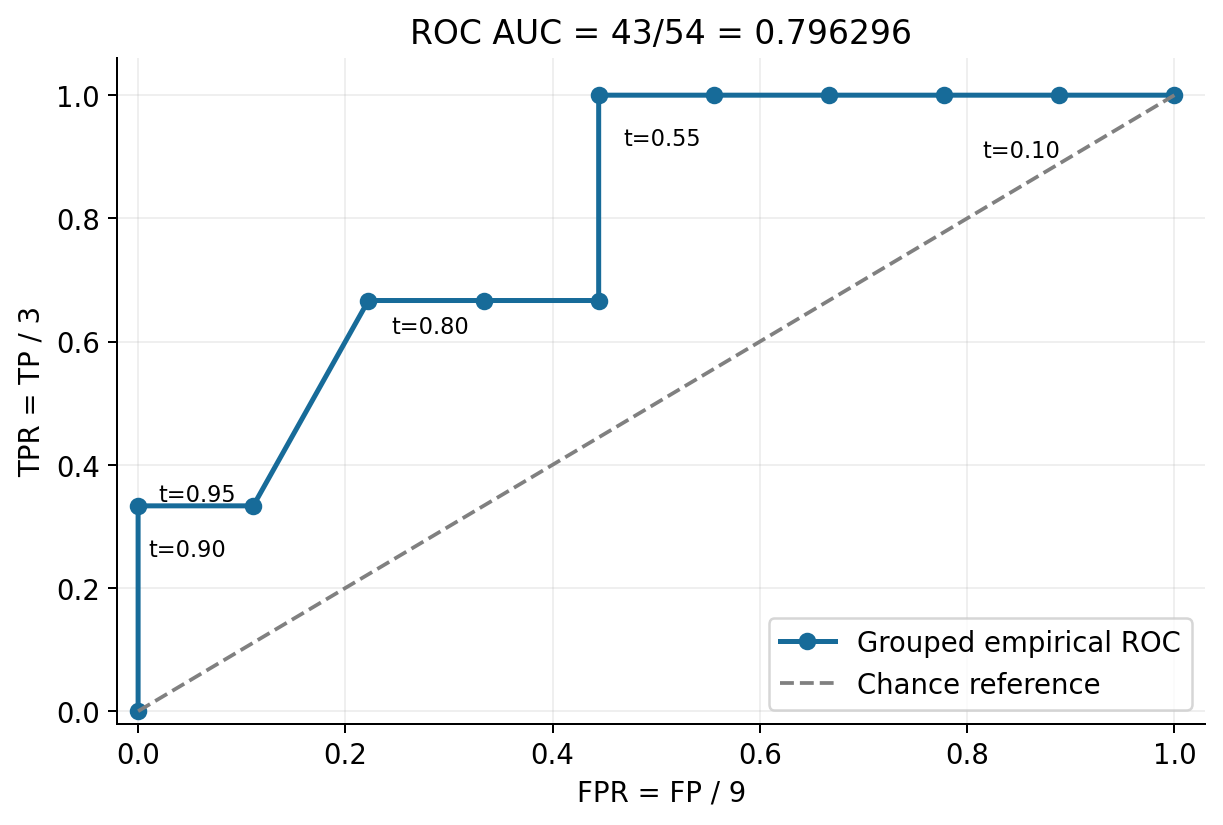

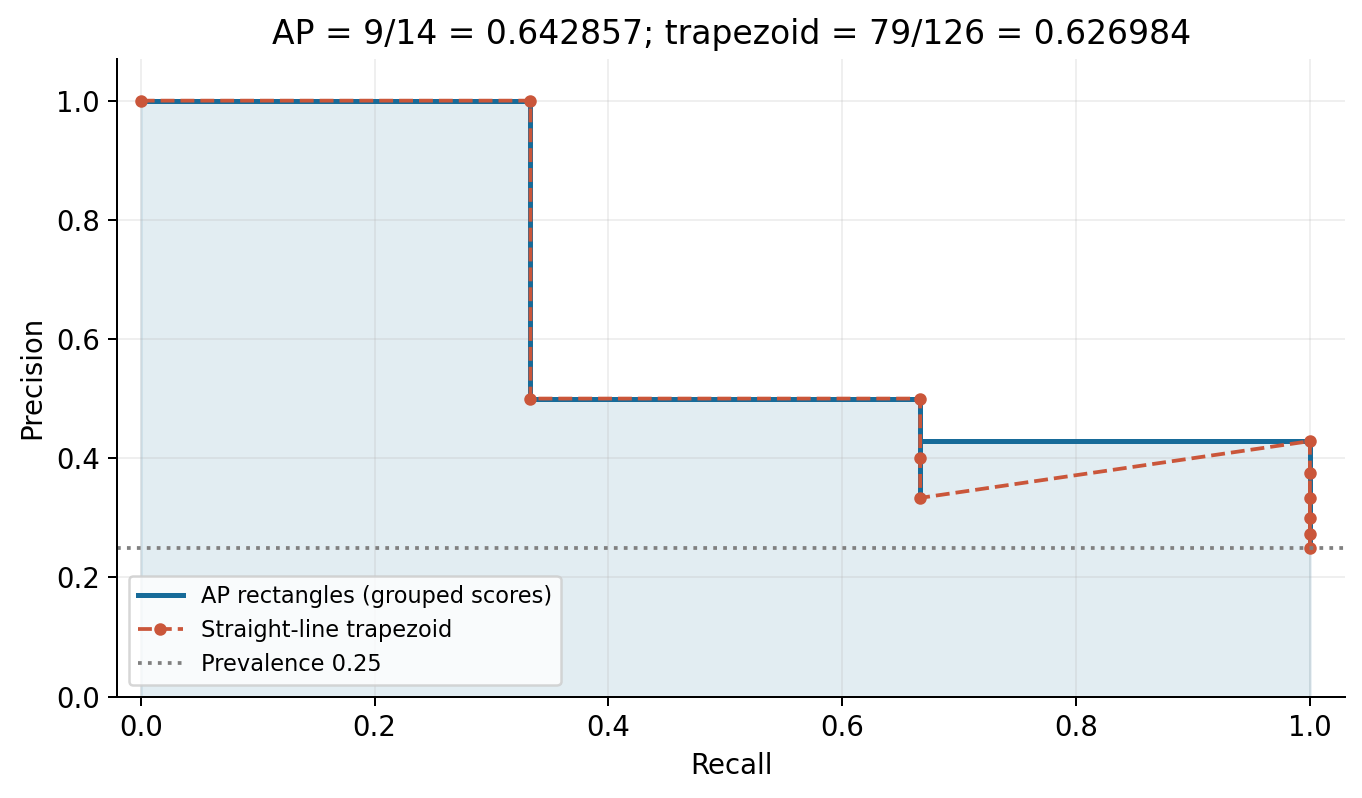

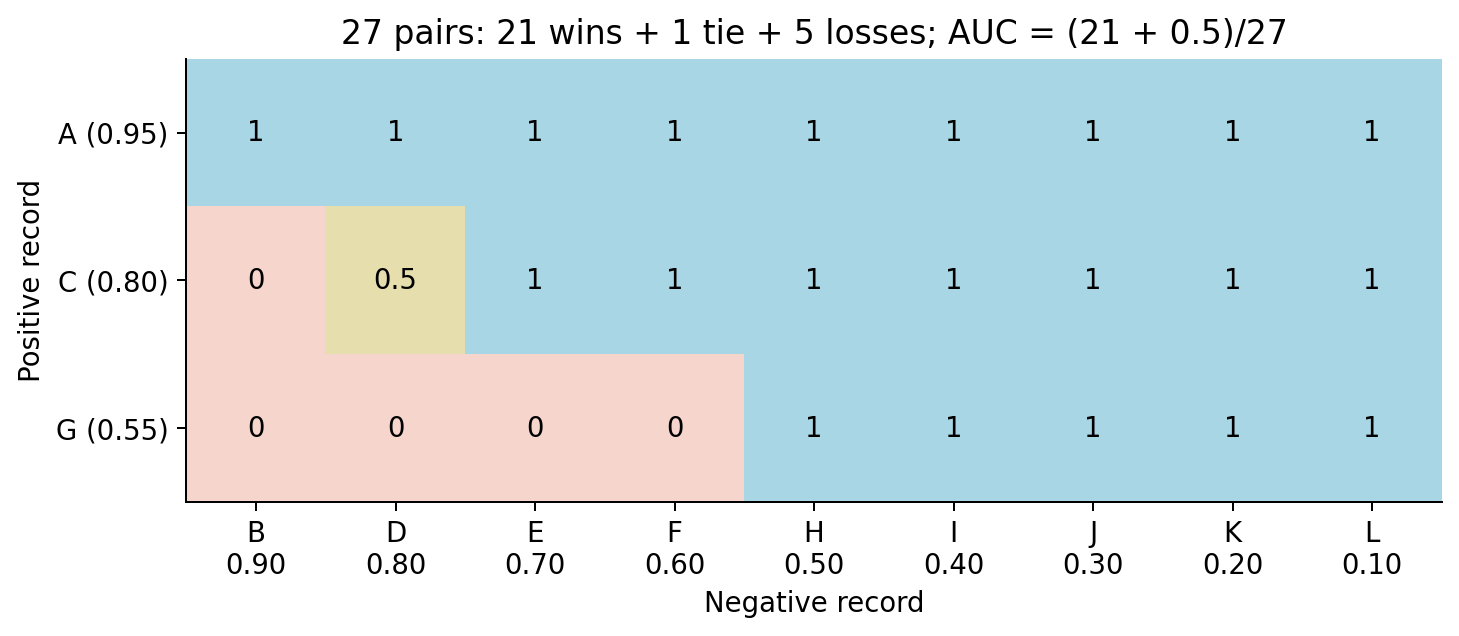

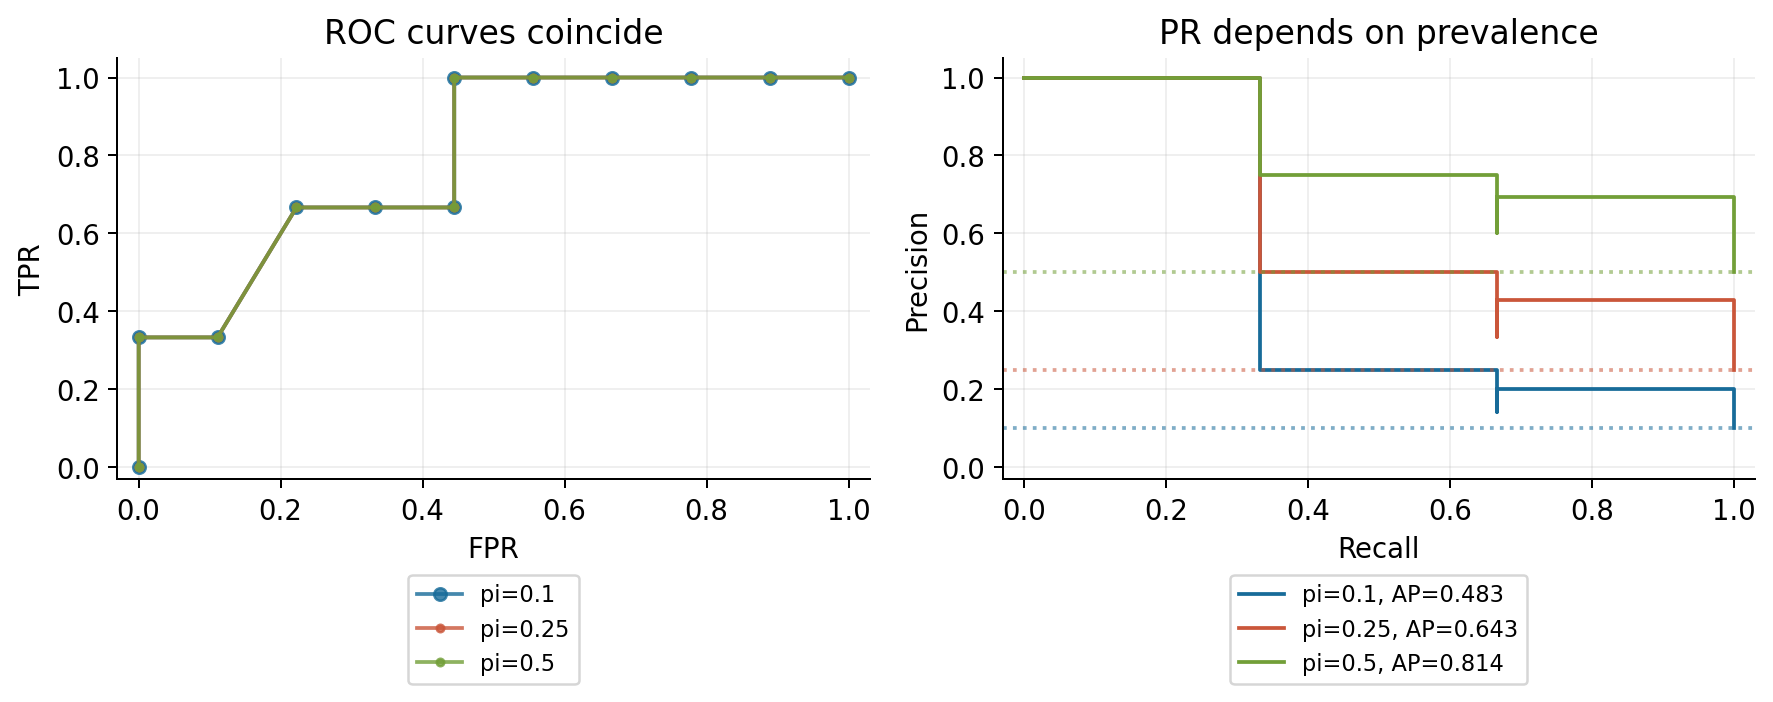

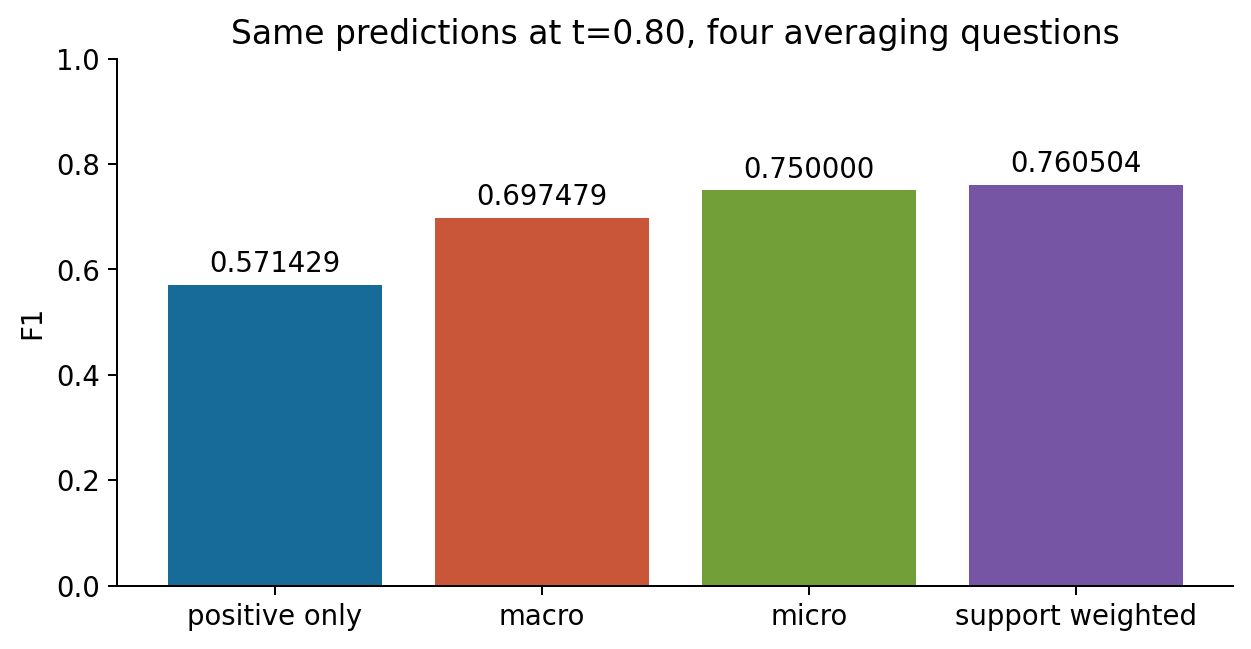

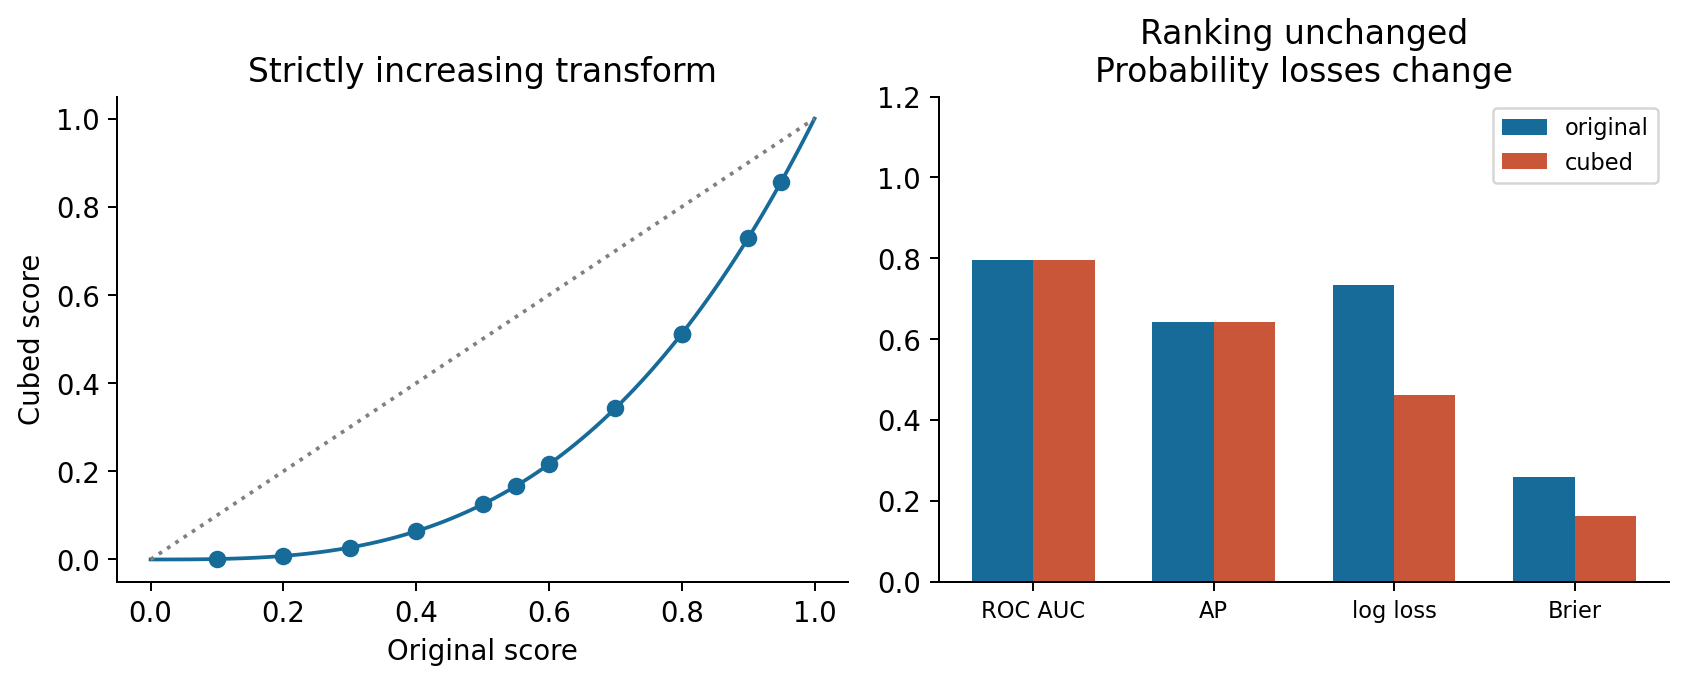

In [11]:
from plots import create_figures
figures = create_figures(root/'outputs/notebook-figures')
for file in figures:
    print(Path(file).name)
    display(Image(filename=file, width=850))

## 12 写结果而非只看图
完成L10报告。必须解释样本、阳性定义、阈值、平均方式、AUC/AP约定与外推限制。对照answers.pdf前保存自己的纸笔答案。

In [12]:
print('Frozen case: TP=2 FP=2 FN=1 TN=7 at threshold .80 (>=).')
print('AUC=43/54 AP=9/14; synthetic teaching data, no generalization claim.')
print('Executed all teaching cells without fitting a model or selecting a threshold.')